In [1]:
%load_ext autoreload
%autoreload 2
import sys
import json
import os
import numpy as np
from collections import defaultdict
from pathlib import Path
project_root = Path(os.getcwd()).parent.parent
print(f'当前目录: {project_root}')
sys.path.append(str(project_root))

from src.envs.single_feeder_multi_agent_env import MultiFeederStorageEnv

当前目录: /Users/steven/Documents/GridProjects/MAGRL


In [ ]:
import ray
from src.train_ma import setup_registry, build_mappo_algo, run_training

# 启动本地计算集群
ray.init(
    ignore_reinit_error=True,
    runtime_env={"working_dir": project_root}
)

env_name = setup_registry()

# 构建算法
algo = build_mappo_algo(
    env_name=env_name, 
    learning_rate=5e-5,                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            
    num_workers=2
)

2026-04-02 16:43:21,558	INFO worker.py:2013 -- Started a local Ray instance.
2026-04-02 16:43:21,564	WARNING working_dir.py:86 -- Directory '.git' is now ignored by default when packaging the working directory. To disable this behavior, set the `RAY_OVERRIDE_RUNTIME_ENV_DEFAULT_EXCLUDES=''` environment variable.
2026-04-02 16:43:21,575	INFO packaging.py:392 -- Ignoring upload to cluster for these files: [PosixPath('/Users/steven/Documents/GridProjects/MAGRL/.gitignore'), PosixPath('/Users/steven/Documents/GridProjects/MAGRL/.rayignore')]
2026-04-02 16:43:21,589	INFO packaging.py:691 -- Creating a file package for local module '/Users/steven/Documents/GridProjects/MAGRL'.
2026-04-02 16:43:21,591	INFO packaging.py:392 -- Ignoring upload to cluster for these files: [PosixPath('/Users/steven/Documents/GridProjects/MAGRL/.gitignore'), PosixPath('/Users/steven/Documents/GridProjects/MAGRL/.rayignore')]
2026-04-02 16:43:21,602	INFO packaging.py:463 -- Pushing file package 'gcs://_ray_pkg_f121

(MultiAgentEnvRunner pid=87330) DeprecationWarning: `RLModule(config=[RLModuleConfig object])` has been deprecated. Use `RLModule(observation_space=.., action_space=.., inference_only=.., model_config=.., catalog_class=..)` instead. This will raise an error in the future!
(MultiAgentEnvRunner pid=87525) DeprecationWarning: `RLModule(config=[RLModuleConfig object])` has been deprecated. Use `RLModule(observation_space=.., action_space=.., inference_only=.., model_config=.., catalog_class=..)` instead. This will raise an error in the future!
(MultiAgentEnvRunner pid=89415) DeprecationWarning: `RLModule(config=[RLModuleConfig object])` has been deprecated. Use `RLModule(observation_space=.., action_space=.., inference_only=.., model_config=.., catalog_class=..)` instead. This will raise an error in the future!


在这里方便地修改超参数进行对比实验

In [3]:
# 设定训练轮数并运行
return_history, best_checkpoint_path, latest_checkpoint_path = run_training(
    algo=algo, 
    iterations=300, 
    # iterations=1000, 
    checkpoint_freq=5,
    # save_dir=
    save_dir=os.path.join(project_root, "checkpoints/mappo_v1")
)

Run directory: /Users/steven/Documents/GridProjects/MAGRL/checkpoints/mappo_v1/run_20260402_164327
TensorBoard: tensorboard --logdir /Users/steven/Documents/GridProjects/MAGRL/checkpoints/mappo_v1/run_20260402_164327/tb_logs
Iteration 001 | Return: -241.63
  ★ New best! Return: -241.63 -> /Users/steven/Documents/GridProjects/MAGRL/checkpoints/mappo_v1/run_20260402_164327/best
Iteration 002 | Return: -217.95
  ★ New best! Return: -217.95 -> /Users/steven/Documents/GridProjects/MAGRL/checkpoints/mappo_v1/run_20260402_164327/best
Iteration 003 | Return: -204.40
  ★ New best! Return: -204.40 -> /Users/steven/Documents/GridProjects/MAGRL/checkpoints/mappo_v1/run_20260402_164327/best
Iteration 004 | Return: -179.69
  ★ New best! Return: -179.69 -> /Users/steven/Documents/GridProjects/MAGRL/checkpoints/mappo_v1/run_20260402_164327/best
Iteration 005 | Return: -168.02
  Checkpoint saved: /Users/steven/Documents/GridProjects/MAGRL/checkpoints/mappo_v1/run_20260402_164327/iter_0005
  ★ New best!

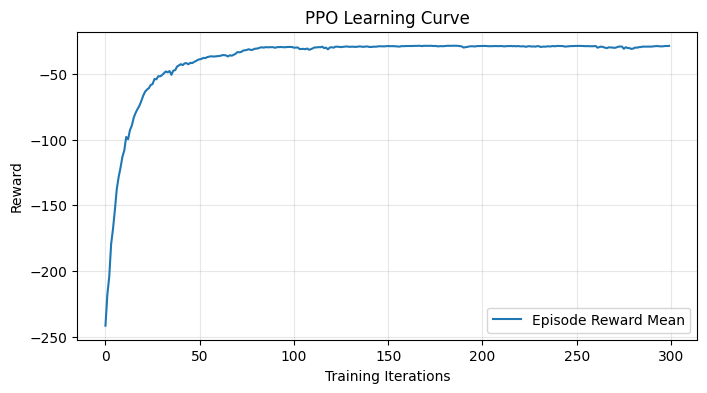

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(return_history, label="Episode Reward Mean")
plt.xlabel("Training Iterations")
plt.ylabel("Reward")
plt.title("PPO Learning Curve")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

2026-04-03 13:48:20,898	INFO worker.py:1831 -- Calling ray.init() again after it has already been called.
/opt/anaconda3/envs/yc_mamaskabledppo_env/lib/python3.11/site-packages/ray/rllib/algorithms/algorithm.py:527: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You could suppress this warning by setting env variable PYTHONWARNINGS="ignore::DeprecationWarning"
`UnifiedLogger` will be removed in Ray 2.7.
  return UnifiedLogger(config, logdir, loggers=None)
/opt/anaconda3/envs/yc_mamaskabledppo_env/lib/python3.11/site-packages/ray/tune/logger/unified.py:53: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You could suppress this warning by setting env variable PYTHONWARNINGS="ignore::DeprecationWarning"
The `JsonLogger interface is deprecated in favor of the `ray.tune.json.JsonLoggerCallback` interface and will be removed in Ray 2.7.
  self._loggers.append(cls(self.config, self.logdir, self.trial))
/opt/ana

[Baseline] Evaluation done: 24 steps, total_return = -70.45, avg_reward = -2.9355
[RL Policy] Evaluation done: 24 steps, total_return = -9.37, avg_reward = -0.3905


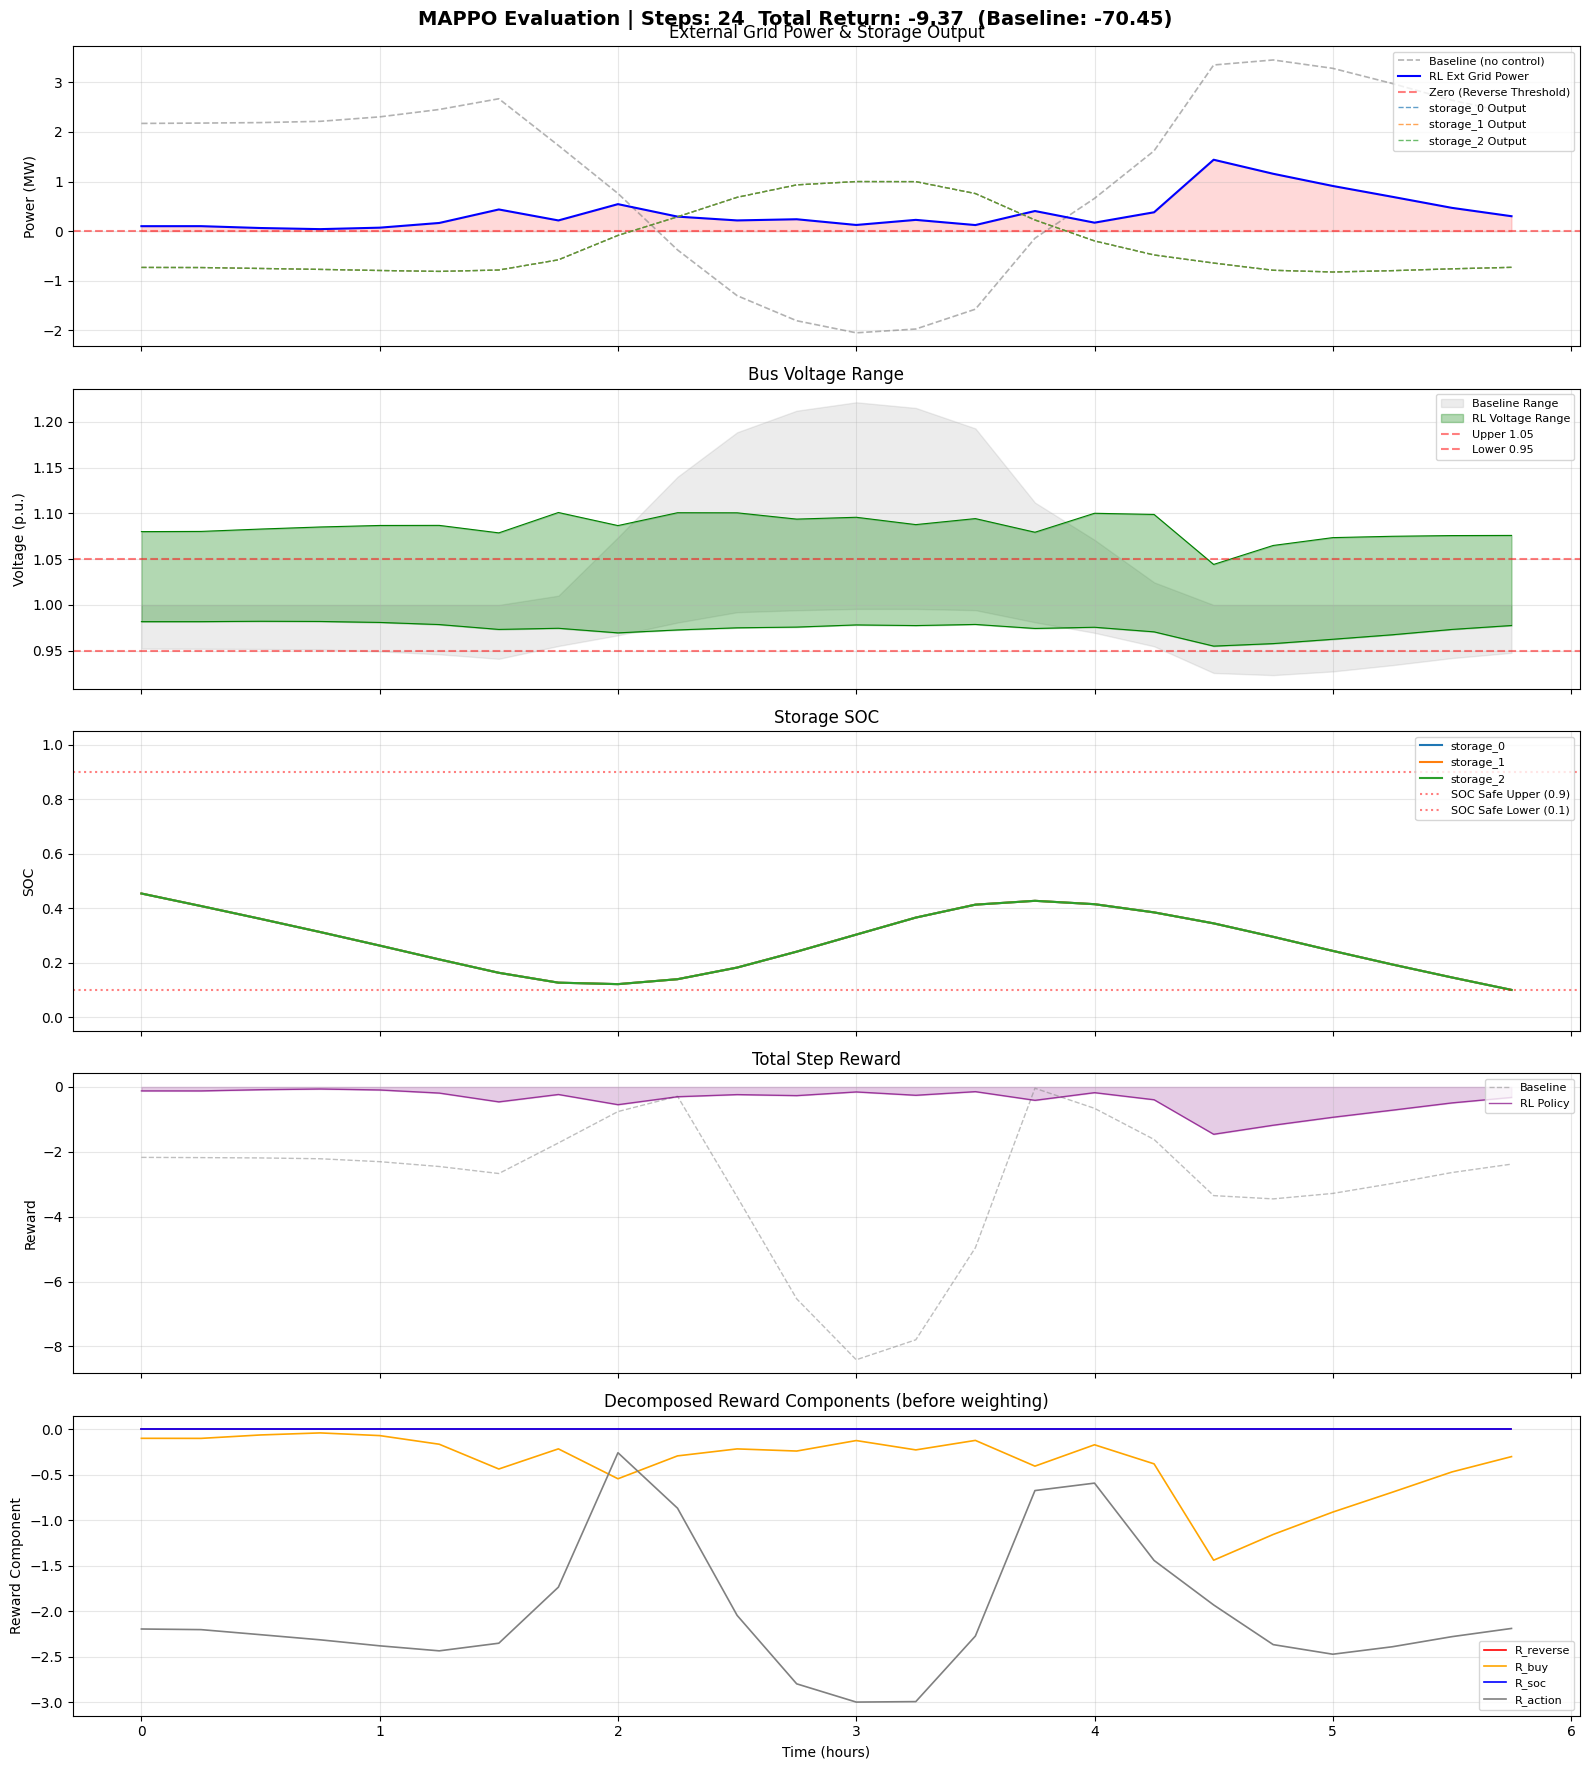

In [11]:
import ray
from ray.rllib.algorithms.ppo import PPO
from src.train_ma import setup_registry
from src.eval_ma import evaluate_episode, plot_evaluation, evaluate_baseline

ray.init(ignore_reinit_error=True, runtime_env={"working_dir": project_root})
env_name = setup_registry()

# 直接从 checkpoint 目录恢复，不需要先 build
algo = PPO.from_checkpoint(os.path.join(project_root, "/Users/steven/Documents/GridProjects/MAGRL/checkpoints/mappo_v1/run_20260402_164327/best"))
baseline = evaluate_baseline(env_config={"data_path": str(project_root) + "/data/generated/ieee_case33bw"})
# 评估
records = evaluate_episode(algo, env_config={"data_path": str(project_root) + "/data/generated/ieee_case33bw"})
fig = plot_evaluation(records, baseline)
